In [ ]:
# ===================== 自动安装所有依赖包=====================
import importlib
import subprocess
import sys

required_packages = ["numpy", "pandas", "matplotlib", "seaborn", "scipy"]
for pkg in required_packages:
    try:
        importlib.import_module(pkg)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])
print("✅ 所有依赖包已准备完成！")

✅ 所有依赖包已准备完成！


In [ ]:
# ===========================清楚环境==============================

%reset -f
# ===========================导入库==============================
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from matplotlib import colors as mcolors
from matplotlib.patches import FancyArrowPatch
import seaborn as sns
import warnings
from scipy.optimize import curve_fit

warnings.filterwarnings('ignore')
pd.set_option('mode.chained_assignment', None)

In [ ]:

# ===================== 工作目录=====================
root_dir = r'C:\Users\11633'
os.makedirs(root_dir, exist_ok=True)
os.chdir(root_dir)

# 图片保存目录（你指定的）
save_fig_dir = r'C:\Users\11633'
os.makedirs(save_fig_dir, exist_ok=True)
# ==================================================================

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

# ===================== 数据读取路径=====================
df_site = pd.read_csv(r"C:\Users\50847\OneDrive\桌面\work\data\sites_meta_info.csv", index_col=0)
df_SNR = pd.read_csv(r"C:\Users\50847\OneDrive\桌面\work\data\beta_SNR_results.csv", index_col=0)
df_delta_Y = pd.read_csv(r"C:\Users\50847\OneDrive\桌面\work\data\delta_Y_CO2_results.csv", index_col=0)

✅ 图片已保存到：
C:\Users\50847\OneDrive\桌面\work\figure\Fig3_heatmap_boxplot.png


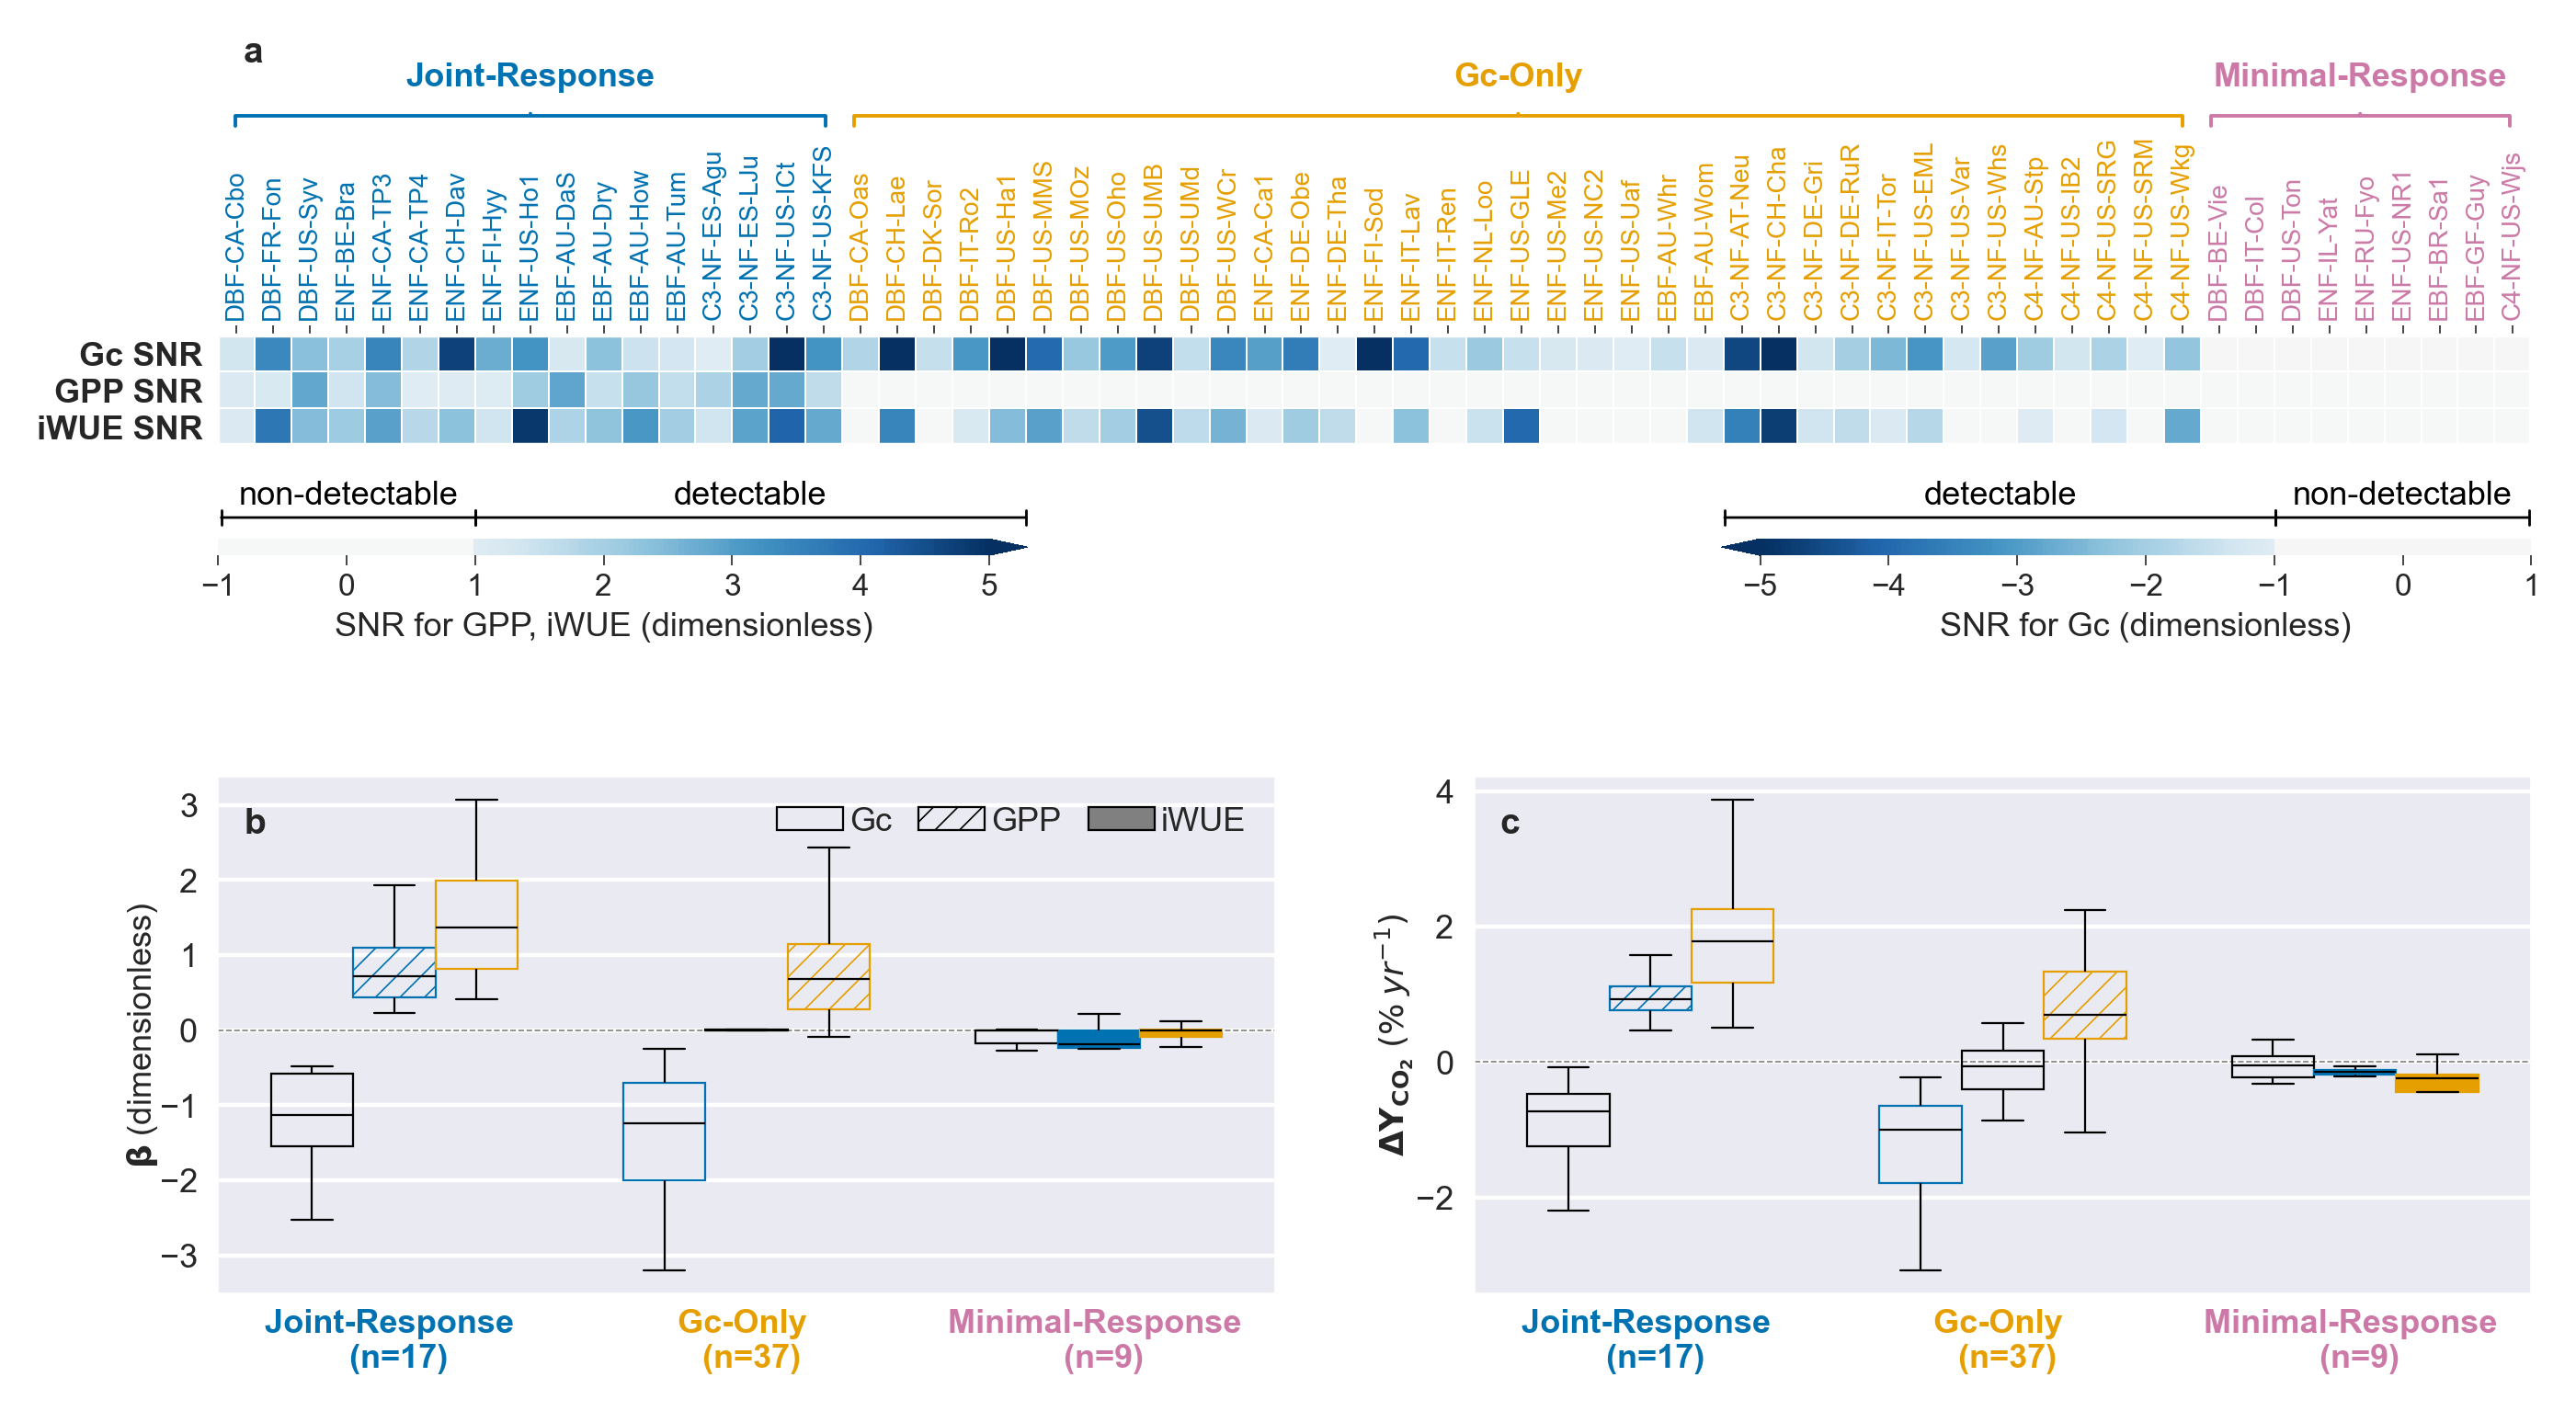

In [ ]:
# ========================绘图=============================
## Fig 3: heatmap of site-specific results
data_SNR = pd.DataFrame(index=df_SNR.index)
targets = ['Gc', 'GPP', 'iWUE']
for var in targets:
    data_SNR[var] = df_SNR[var + '_SNR'].values

data_beta = pd.DataFrame(index=df_SNR.index)
targets = ['Gc', 'GPP', 'iWUE']
for var in targets:
    data_beta[var] = df_SNR[var + '_beta'].values

data_decomp = pd.DataFrame(index=df_delta_Y.index)
targets = ['Gc', 'GPP', 'iWUE']
for target in targets:
    data_decomp[target] = df_delta_Y['delta_' + target + '_CO2'].values
cluster_color_dic = {1: '#0072B2', 2: '#E69F00', 3: '#CC79A7'}
fontsize = 6.5

plt.rcParams["legend.frameon"] = False
plt.rcParams['savefig.dpi'] = 800
plt.rcParams['font.size'] = fontsize
plt.rcParams['font.family'] = 'Arial'


def customized_asymmetric_cmap_breakpoint(default_cmap, vmin, vmax, break_abs, gap,
                                          left_part=True):
    cmap = plt.get_cmap(default_cmap)

    N = cmap.N
    break1 = int(N / (vmax - vmin) * (-break_abs - vmin))
    break2 = int(N / (vmax - vmin) * (break_abs - vmin))
    middle = N // 2

    colors = [cmap(i) for i in range(cmap.N)]

    if left_part:
        left_half = colors[:middle - gap]
        n_org = len(left_half)

        assert n_org > break1
        indices = np.linspace(0, n_org - 1, break1).astype(int)
        left_half = [left_half[i] for i in indices]

        colors = np.concatenate([left_half, [cmap(middle)] * (break2 - break1)])

    else:
        right_half = colors[middle + gap:]
        n_org = len(right_half)

        assert n_org > N - break2
        indices = np.linspace(0, n_org - 1, N - break2).astype(int)
        right_half = [right_half[i] for i in indices]

        colors = np.concatenate([[cmap(middle)] * (break2 - break1), right_half])

    custom_cmap = mcolors.LinearSegmentedColormap.from_list('CustomRdBu', colors, len(colors))

    return custom_cmap


def get_color(i, cluster_color_dic):
    if i in [1, 3, 5]:
        return cluster_color_dic[1]
    if i in [6, 7, 8]:
        return cluster_color_dic[2]
    if i in [9, 10, 11]:
        return cluster_color_dic[3]


def plot_heatmap_SNR_alltargets(df_SNR_all, df_sort_update,
                                fig, ax, cluster_color_dic,
                                var_plot=['Gc', 'GPP', 'iWUE'],
                                cluster_new='new_ID', fontsize=fontsize, gap=10):
    cbar_abs_min = 1
    cbar_abs_max = 5
    lw = 0.3
    warm2blue, blue2warm = 'RdBu', 'RdBu_r'

    warm2blue = customized_asymmetric_cmap_breakpoint(warm2blue, -cbar_abs_max, cbar_abs_max, 1, gap, left_part=False)
    blue2warm = customized_asymmetric_cmap_breakpoint(blue2warm, -cbar_abs_max, cbar_abs_max, 1, gap, left_part=True)

    data = df_SNR_all[var_plot].transpose()

    row_labels = [idx + ' SNR' for idx in data.index.tolist()]
    col_labels = df_sort_update.Cover_type + '-' + data.columns
    col_colors = [cluster_color_dic[ID] for ID in df_sort_update[cluster_new].tolist()]

    data1 = data.copy()
    var1 = ['GPP', 'iWUE']
    data1[~data1.index.isin(var1)] = np.nan

    ny, nx = data1.values.shape
    im1 = ax.pcolormesh(np.arange(nx + 1) - 0.5, np.arange(ny + 1) - 0.5, data1.values,
                        cmap=warm2blue, vmin=-cbar_abs_min, vmax=cbar_abs_max,
                        edgecolors='w', linewidth=lw)

    data2 = data.copy()
    var2 = ['Gc']
    data2[~data2.index.isin(var2)] = np.nan

    ny, nx = data2.values.shape
    im2 = ax.pcolormesh(np.arange(nx + 1) - 0.5, np.arange(ny + 1) - 0.5, data2.values,
                        cmap=blue2warm, vmin=-cbar_abs_max, vmax=cbar_abs_min,
                        edgecolors='w', linewidth=lw)

    c_pad = 8
    t_pad = 1.5
    cax1 = ax.inset_axes([0, -1, 0.35, 0.15])
    cbar1 = fig.colorbar(im1, ax=ax, cax=cax1, aspect=60, shrink=0.4,
                         extend='max', orientation='horizontal', pad=0)
    cbar1.ax.tick_params(labelsize=fontsize - 0.5, width=0.3, length=2, pad=t_pad)
    cbar1.ax.set_xlabel(f'SNR for ' + (', ').join(var1) + ' (dimensionless)',
                        rotation=0, va="bottom", fontsize=fontsize, labelpad=c_pad)
    cbar1.outline.set_visible(False)

    cax2 = ax.inset_axes([0.65, -1, 0.35, 0.15])
    cbar2 = fig.colorbar(im2, ax=ax, cax=cax2, aspect=60, shrink=0.4,
                         extend='min', orientation='horizontal', pad=0)
    cbar2.ax.tick_params(labelsize=fontsize - 0.5, width=0.3, length=2, pad=t_pad)
    cbar2.ax.set_xlabel(f'SNR for ' + (', ').join(var2) + ' (dimensionless)',
                        rotation=0, va="bottom", fontsize=fontsize, labelpad=c_pad)
    cbar2.outline.set_visible(False)

    n_y, n_x = data.shape
    ax.set_xticks(np.arange(0, n_x, 1), labels=col_labels, fontsize=fontsize - 1.5, rotation=90)
    ax.set_yticks(np.arange(0, n_y, 1), labels=row_labels, fontsize=fontsize, fontweight='bold')
    ax.tick_params(top=True, bottom=False, labeltop=True, labelbottom=False)
    ax.tick_params(width=0.3, length=2)
    ax.tick_params(axis='x', pad=1)
    ax.tick_params(axis='y', pad=1)

    ax.set_xticks(np.arange(-.5, n_x, 1), minor=True)
    ax.set_yticks(np.arange(-.5, n_y, 1), minor=True)
    ax.tick_params(which='minor', bottom=False, left=False)
    ax.spines[:].set_color('white')
    for i, tick in enumerate(ax.get_xticklabels()):
        tick.set_color(col_colors[i])


plt.rcParams['hatch.linewidth'] = 0.3


def boxplot_three_patterns(data, fig, ax, cluster_color_dic, legend_loc, legend=False):
    list = []
    for var in ['Gc', 'GPP', 'iWUE']:
        df_var = data[[var, 'new_ID']].reset_index()
        df_var = df_var.rename(columns={var: 'value'})
        df_var['var'] = var
        list.append(df_var)
    df_boxplot = pd.concat(list, axis=0)
    df_boxplot = df_boxplot.reset_index(drop=True)

    ax.axhline(y=0, color='black', linestyle='--', linewidth=0.3, alpha=0.5)
    boxplot = sns.boxplot(x='new_ID', y='value', data=df_boxplot, hue='var',
                          saturation=1, ax=ax,
                          fliersize=3, showfliers=False, width=0.7, linewidth=0.4)
    for i, line in enumerate(boxplot.get_lines()):
        line.set_color('black')

    boxplot.legend_.remove()

    if legend:
        handles, labels = boxplot.get_legend_handles_labels()
        l = ax.legend(handles, labels, title=None, bbox_to_anchor=legend_loc,
                      loc='upper left', ncols=3, columnspacing=0.8, handletextpad=0.2)
        for i, lp, in enumerate(l.get_patches()):
            if i == 0:
                lp.set_facecolor('none')
            if i == 1:
                lp.set_facecolor('none')
                lp.set_hatch('/////')
            if i == 2:
                lp.set_facecolor('grey')
            lp.set_edgecolor('black')

    for i, patch, in enumerate(boxplot.patches):
        patch.set_edgecolor('black')
        patch.set_facecolor('none')

        if i in [1, 6, 9]:
            patch.set_hatch('')
            patch.set_edgecolor(get_color(i, cluster_color_dic))

        if i in [3, 7, 10]:
            patch.set_hatch('/////')
            patch.set_edgecolor(get_color(i, cluster_color_dic))

        if i in [5, 8, 11]:
            patch.set_facecolor(get_color(i, cluster_color_dic))
            patch.set_edgecolor(get_color(i, cluster_color_dic))


fig_w, fig_h = 15, 8.5
width_new = 7
height_new = fig_h / fig_w * width_new

fig = plt.figure(figsize=(width_new, height_new), dpi=200)

shape = (7, 2)
ax1 = plt.subplot2grid(shape, loc=(0, 0), colspan=2, rowspan=4)
ax2 = plt.subplot2grid(shape, (4, 0), colspan=1, rowspan=3)
ax3 = plt.subplot2grid(shape, (4, 1), colspan=1, rowspan=3)

plot_heatmap_SNR_alltargets(data_SNR, df_SNR,
                            fig, ax1, cluster_color_dic,
                            var_plot=['Gc', 'GPP', 'iWUE'], gap=15)

ax1.set_aspect('equal')
ax1.invert_yaxis()

x1, x2 = 0.0814, 0.188
y = 0.616
start = (x1, y)
end = (x2, y)
arrow = FancyArrowPatch(start, end, arrowstyle='|-|,widthA=0.1,widthB=0.1',
                        mutation_scale=15, color='black', linewidth=0.5)
fig.add_artist(arrow)
fig.text((x1 + x2) / 2, y + 0.015, 'non-detectable',
         ha='center', va='center', fontsize=fontsize, color='black')

x1 += 0.747 + 0.045 + 0.006
x2 += 0.747 + 0.045 + 0.006
start = (x1, y)
end = (x2, y)
arrow = FancyArrowPatch(start, end, arrowstyle='|-|,widthA=0.1,widthB=0.1',
                        mutation_scale=15, color='black', linewidth=0.5)
fig.add_artist(arrow)
fig.text((x1 + x2) / 2, y + 0.015, 'non-detectable',
         ha='center', va='center', fontsize=fontsize, color='black')

x1 = 0.18
x2 = x1 + 0.222
start = (x1, y)
end = (x2, y)
arrow = FancyArrowPatch(start, end, arrowstyle='|-|,widthA=0.1,widthB=0.1',
                        mutation_scale=15, color='black', linewidth=0.5)
fig.add_artist(arrow)
fig.text((x1 + x2) / 2, y + 0.015, 'detectable',
         ha='center', va='center', fontsize=fontsize, color='black')

x1 += 0.4355 + 0.0449 + 0.005
x2 += 0.4355 + 0.0449 + 0.005
start = (x1, y)
end = (x2, y)
arrow = FancyArrowPatch(start, end, arrowstyle='|-|,widthA=0.1,widthB=0.1',
                        mutation_scale=15, color='black', linewidth=0.5)
fig.add_artist(arrow)
fig.text((x1 + x2) / 2, y + 0.015, 'detectable',
         ha='center', va='center', fontsize=fontsize, color='black')

y_loc = 2.9
label_fontsize = fontsize
y_dis = 0.3
lw = 0.7

ax1.annotate('Joint-Response', xy=(0.135, y_loc), xytext=(0.135, y_loc + y_dis), xycoords='axes fraction',
             fontsize=label_fontsize, ha='center', va='bottom', color=cluster_color_dic[1], fontweight='bold',
             arrowprops=dict(arrowstyle='-[, widthB=8.9, lengthB=0.3', lw=lw, color=cluster_color_dic[1]),
             textcoords='axes fraction')

ax1.annotate('Gc-Only', xy=(0.562, y_loc), xytext=(0.562, y_loc + y_dis), xycoords='axes fraction',
             fontsize=label_fontsize, ha='center', va='bottom', color=cluster_color_dic[2], fontweight='bold',
             arrowprops=dict(arrowstyle='-[, widthB=20, lengthB=0.3', lw=lw, color=cluster_color_dic[2]),
             textcoords='axes fraction')

ax1.annotate('Minimal-Response', xy=(0.926, y_loc), xytext=(0.926, y_loc + y_dis), xycoords='axes fraction',
             fontsize=label_fontsize, ha='center', va='bottom', color=cluster_color_dic[3], fontweight='bold',
             arrowprops=dict(arrowstyle='-[, widthB=4.5, lengthB=0.3', lw=lw, color=cluster_color_dic[3]),
             textcoords='axes fraction')

data = data_beta.merge(df_SNR['new_ID'], left_index=True, right_index=True)
boxplot_three_patterns(data, fig, ax2, cluster_color_dic, (0.5, 1), legend=True)

data = data_decomp.merge(df_SNR['new_ID'], left_index=True, right_index=True)
boxplot_three_patterns(data, fig, ax3, cluster_color_dic, (0.55, 1), legend=False)

ylabels = [r'$\mathbf{\beta}$ (dimensionless)', r'$\mathbf{\Delta Y_{CO_2}}$ $(\% \: yr^{-1})$']
subpanel = ['b', 'c']
n_list = [df_SNR[df_SNR['new_ID'] == i + 1].shape[0] for i in range(3)]

for i, ax in enumerate([ax2, ax3]):
    ax.set_ylabel(ylabels[i], fontsize=fontsize, labelpad=0)
    ax.set_xticklabels([f'Joint-Response \n (n={n_list[0]})',
                        f'Gc-Only \n (n={n_list[1]})',
                        f'Minimal-Response \n (n={n_list[2]})'],
                       fontweight='bold', fontsize=fontsize)
    ax.set_xlabel('')
    ax.annotate(subpanel[i], xy=(5, 90), xycoords='axes points', fontweight='bold', fontsize=fontsize + 0.5)
    for i, tick in enumerate(ax.get_xticklabels()):
        tick.set_color(cluster_color_dic[i + 1])

    ax.tick_params(width=0.3, length=2)
    ax.tick_params(axis='x', pad=1)
    ax.tick_params(axis='y', pad=2)

    for spine in ax.spines.values():
        spine.set_linewidth(0.3)

ax1.annotate('a', xy=(5, 75), xycoords='axes points', fontweight='bold', fontsize=fontsize + 0.5)

plt.tight_layout()

# ===================== 【自动保存图片】=====================
save_path = os.path.join(save_fig_dir, 'Fig3_heatmap_boxplot.png')
plt.savefig(save_path, dpi=800, bbox_inches='tight')
print(f"✅ 图片已保存到：\n{save_path}")
# ==========================================================

plt.show()